In [2]:
import numpy as np 
import pandas as pd

In [3]:
# Load data and perform SVD
data = pd.read_csv('Math_232_Data/processed_data.csv')
data = data.iloc[:, 1:] # remove the timestamp column
data.head()

,Value_1,Value_2,Value_3,Value_4,Value_5,Value_6,Value_7,Value_8,Value_9,Value_10,...,Value_71,Value_72,Value_73,Value_74,Value_75,Value_76,Value_77,Value_78,Value_79,Value_80
0,-101.6,-100.200000,-101.80,-102.200000,-102.2,-102.200000,-102.000000,-101.800000,-99.6,-101.60,...,-99.600000,-100.600000,-100.4,-100.4,-99.000000,-100.000000,-100.6,-99.8,-99.8,-100.0
1,-101.6,-100.100000,-101.80,-102.300000,-102.2,-102.200000,-101.900000,-101.800000,-99.6,-101.60,...,-99.600000,-100.500000,-100.4,-100.4,-99.100000,-100.000000,-100.6,-99.8,-99.8,-100.0
2,-101.6,-100.133333,-101.80,-102.333333,-102.2,-102.266667,-101.866667,-101.733333,-99.6,-101.60,...,-99.666667,-100.533333,-100.4,-100.4,-99.066667,-99.933333,-100.6,-99.8,-99.8,-100.0
3,-101.6,-100.150000,-101.80,-102.350000,-102.2,-102.300000,-101.850000,-101.750000,-99.6,-101.55,...,-99.650000,-100.550000,-100.4,-100.4,-99.100000,-99.900000,-100.6,-99.8,-99.8,-100.0
4,-101.6,-100.160000,-101.84,-102.320000,-102.2,-102.280000,-101.840000,-101.760000,-99.6,-101.56,...,-99.640000,-100.560000,-100.4,-100.4,-99.080000,-99.880000,-100.6,-99.8,-99.8,-100.0


In [4]:
print(data.shape)

(3115, 80)


In [6]:
X = data.values

# Calculate mean center (mean across rows, axis=1)
mean_center = np.mean(X, axis=1)  # This gives an m×1 vector

# Reshape mean_center to be a column vector for proper broadcasting
mean_center = mean_center.reshape(-1, 1)  # Makes it m×1 explicitly

# Create the mean-centered matrix B by subtracting mean_center from each column
B = X - mean_center  # Broadcasting will subtract mean_center from each column

U, s, Vt = np.linalg.svd(B, full_matrices=False)

print(f"U shape: {U.shape}")
print(f"s shape: {s.shape}")
print(f"Vt shape: {Vt.shape}")

U shape: (3115, 80)
s shape: (80,)
Vt shape: (80, 80)


In [7]:
mean_center.shape

(3115, 1)

In [8]:
B

array([[-0.67      ,  0.73      , -0.87      , ...,  1.13      ,
         1.13      ,  0.93      ],
       [-0.67      ,  0.83      , -0.87      , ...,  1.13      ,
         1.13      ,  0.93      ],
       [-0.67      ,  0.79666667, -0.87      , ...,  1.13      ,
         1.13      ,  0.93      ],
       ...,
       [-0.606     , -0.286     , -0.086     , ..., -0.006     ,
        -0.326     , -0.326     ],
       [-0.6105    , -0.2905    , -0.0905    , ..., -0.0105    ,
        -0.3305    , -0.3705    ],
       [-0.653     , -0.293     , -0.093     , ..., -0.013     ,
        -0.333     , -0.373     ]])

Now we can visualize the covariance matrix $BB^T$

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

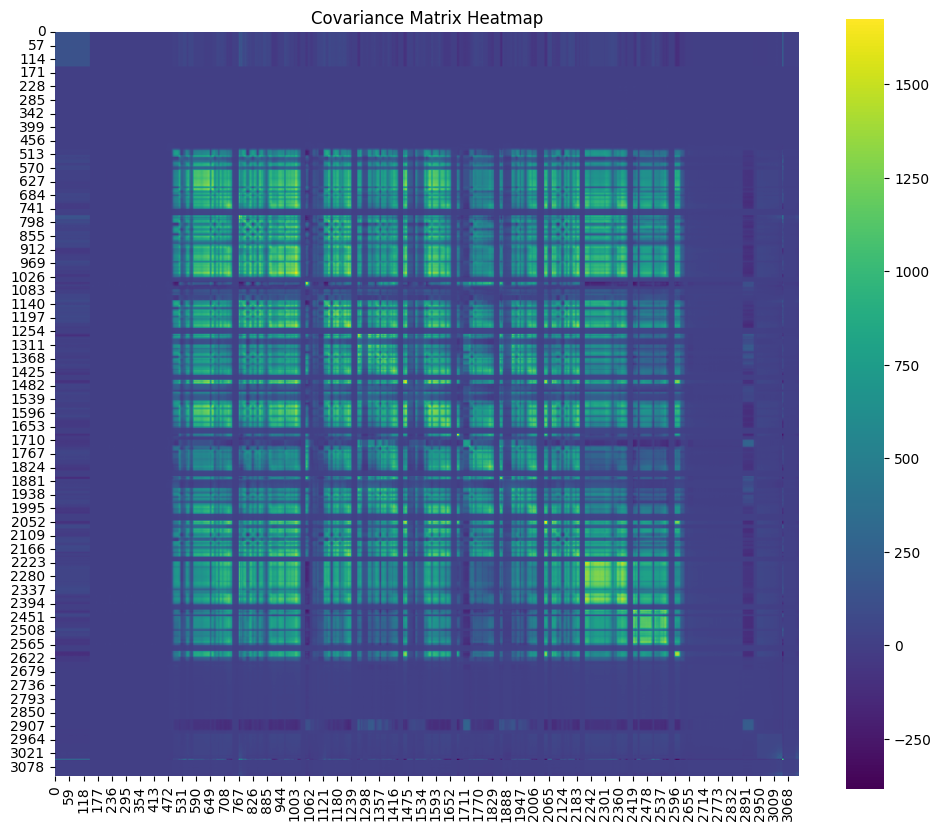

Shape of covariance matrix: (3115, 3115)

Maximum value: 1675.14488
Minimum value: -383.7654
Mean value: 178.42946890267834


In [10]:
covariance_matrix = B @ B.T

plt.figure(figsize=(12, 10))
sns.heatmap(covariance_matrix, 
            cmap='viridis',
            square=True)
plt.title('Covariance Matrix Heatmap')
plt.show()

# Print some basic statistics about the covariance matrix
print("Shape of covariance matrix:", covariance_matrix.shape)
print("\nMaximum value:", np.max(covariance_matrix))
print("Minimum value:", np.min(covariance_matrix))
print("Mean value:", np.mean(covariance_matrix))

# PCA

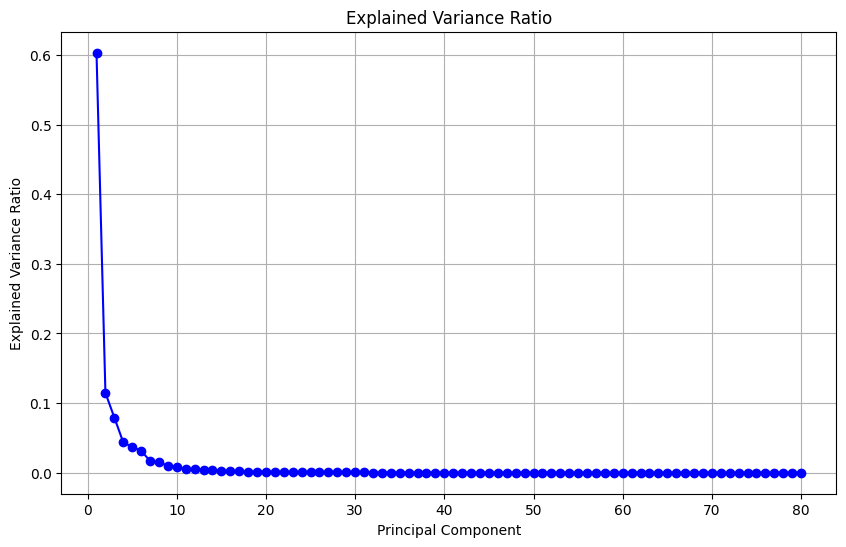

In [14]:
# Calculate the principal components (PCs)
# The columns of Vt are the right singular vectors (eigenvectors of B^T B)
PCs = Vt.T  # This gives us the principal components

# Calculate the scores (projections of the data onto the PCs)
scores = B @ PCs

# Calculate the explained variance ratio
total_var = np.sum(s**2)
explained_var_ratio = (s**2) / total_var

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_var_ratio) + 1), explained_var_ratio, 'bo-')
plt.title('Explained Variance Ratio')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

In [15]:
# Print the cumulative explained variance
cumulative_var = np.cumsum(explained_var_ratio)
print("Cumulative explained variance ratio:")
for i, var in enumerate(cumulative_var):
    print(f"PC{i+1}: {var:.4f}")

Cumulative explained variance ratio:
PC1: 0.6033
PC2: 0.7180
PC3: 0.7973
PC4: 0.8408
PC5: 0.8779
PC6: 0.9094
PC7: 0.9265
PC8: 0.9416
PC9: 0.9517
PC10: 0.9596
PC11: 0.9649
PC12: 0.9699
PC13: 0.9736
PC14: 0.9770
PC15: 0.9799
PC16: 0.9823
PC17: 0.9843
PC18: 0.9861
PC19: 0.9876
PC20: 0.9889
PC21: 0.9901
PC22: 0.9912
PC23: 0.9922
PC24: 0.9931
PC25: 0.9939
PC26: 0.9947
PC27: 0.9953
PC28: 0.9959
PC29: 0.9964
PC30: 0.9968
PC31: 0.9971
PC32: 0.9975
PC33: 0.9977
PC34: 0.9980
PC35: 0.9982
PC36: 0.9984
PC37: 0.9986
PC38: 0.9987
PC39: 0.9989
PC40: 0.9990
PC41: 0.9991
PC42: 0.9992
PC43: 0.9993
PC44: 0.9993
PC45: 0.9994
PC46: 0.9995
PC47: 0.9995
PC48: 0.9996
PC49: 0.9996
PC50: 0.9997
PC51: 0.9997
PC52: 0.9997
PC53: 0.9998
PC54: 0.9998
PC55: 0.9998
PC56: 0.9998
PC57: 0.9998
PC58: 0.9999
PC59: 0.9999
PC60: 0.9999
PC61: 0.9999
PC62: 0.9999
PC63: 0.9999
PC64: 0.9999
PC65: 0.9999
PC66: 0.9999
PC67: 1.0000
PC68: 1.0000
PC69: 1.0000
PC70: 1.0000
PC71: 1.0000
PC72: 1.0000
PC73: 1.0000
PC74: 1.0000
PC75: 1.00

Scree plot suggests we should use around 4-6 PCs. Cumulative variance for the first 4 PCs is > 80%, which is good enough.

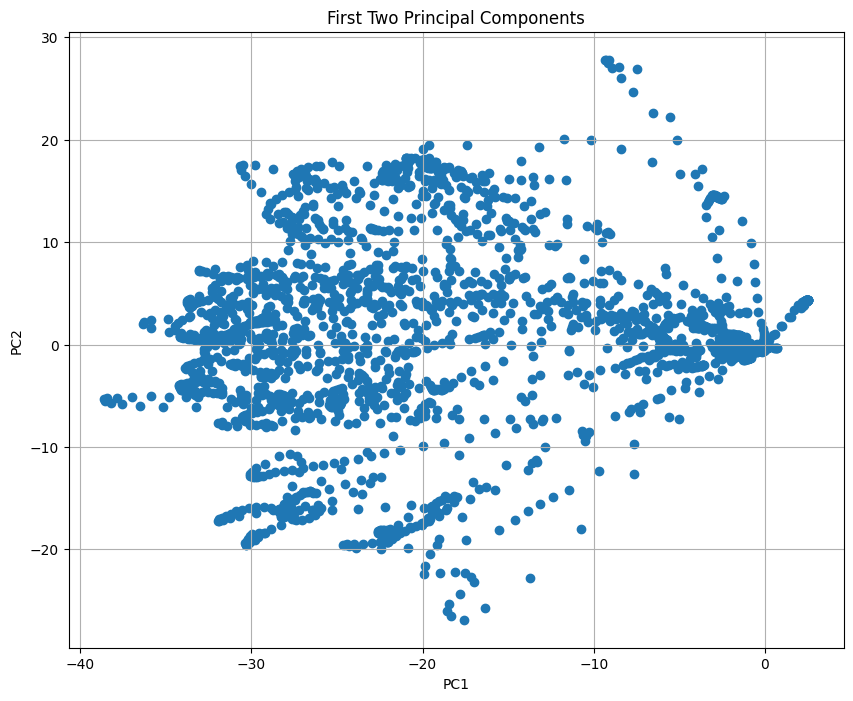

In [16]:
# Plot the first two principal components
plt.figure(figsize=(10, 8))
plt.scatter(scores[:, 0], scores[:, 1])
plt.title('First Two Principal Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

It seems the data is not very well separated ):

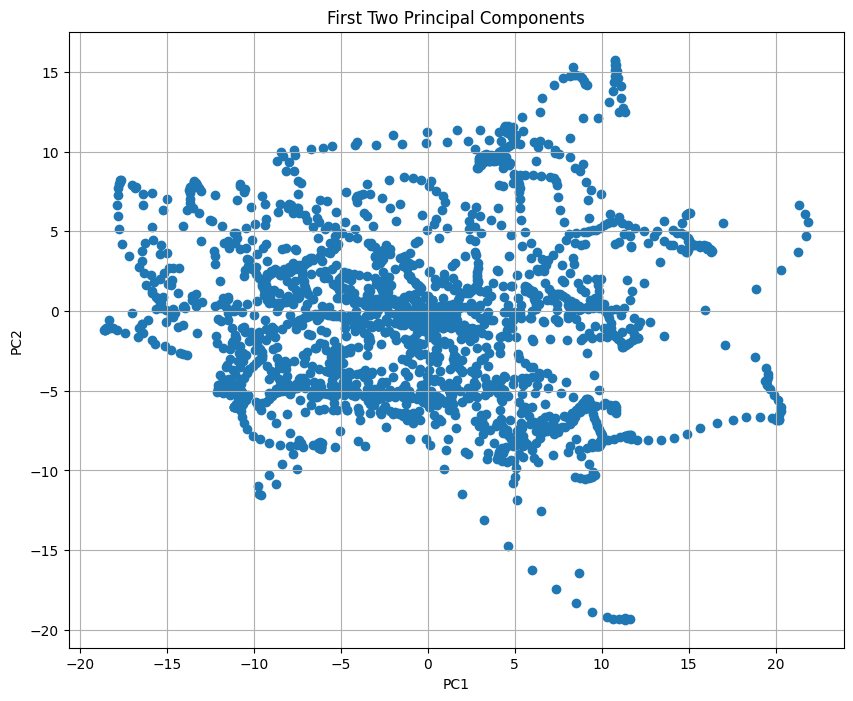

In [19]:
plt.figure(figsize=(10, 8))
plt.scatter(scores[:, 2], scores[:, 4])
plt.title('First Two Principal Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()